# Project Output - Investigation into the Collatz Sequence

## Important Note

This document is a PDF export of the main Jupyter notebook used for the investigation.

For full access to the project, including all Python files, code structure, and generated outputs, please refer to the GitHub repository: https://github.com/georgeramble/MATH2002-Collatz-Investigation

The repository contains the complete work for each section, allowing you to review and run the whole code.  


## Overview

This notebook summarises the python code used in our investigation of the Collatz Sequence and focuses on explaining our work. It will guide through the main functions we created, how we generated data and what mathematical conclusions we can take from these outputs.

The main sections to this investigation are:
- Standard behaviour of the Collatz sequence
- S2
- Variants of the Collatz Sequence
- The Collatz Tree

The python libraries (imported below), have been used within the project, in order to visualise sequence behaviour and help perform mathematical operations.

In [119]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Prologue: The Collatz Function

The Collatz sequence is a well-known sequence that starts at a given positive integer and repeatedly iterates the function below.

$$
f(n) =
\begin{cases}
\frac{n}{2}, & \text{if } n \text{ is even} \\
3n + 1, & \text{if } n \text{ is odd}
\end{cases}
$$

This sequence is particularly famous due to the Collatz conjecture, which states that for every positive integer, the sequence will eventually reach 1. However, although this behaviour has been observed for many values of the sequence, the conjecture still remains unproven mathematically.

Of course, this project is not focused on proving this conjecture. Instead, the Collatz sequence is an interesting example of an integer sequence, which we use to explore and investigate the different properties it exhibits in Python.

This provides the starting point of our project, with the first tasks being to construct core functions that define the Collatz sequence.

### Function: one Collatz step

To begin we created the simple function ```one_step()``` that performs one iteration of the Collatz sequence, also known as a Collatz step. By implementing this, we now have a fundamental idea that can be developed into a function that can perform the full sequence.

We also created a helper function: ```validate_input()``` as an additional checking tool, which rejects invalid inputs - only allowing for positive integers.

In [120]:
def validate_input(n):
    '''
    Checks if input is valid (researched how to raise TypeError)
    '''
    
    if type(n) != int:
        raise TypeError("n must be an integer")
    if n <= 0:
        raise ValueError("n must be positive")

In [121]:
try:
    validate_input(2.1)
except Exception as e:
    print(e)

try:
    validate_input(0)
except Exception as e:
    print(e)

validate_input(1)
print("Valid input works correctly")

n must be an integer
n must be positive
Valid input works correctly


In [122]:
def one_step(n):
    '''
    Does one step of the Collatz seq
    '''
    validate_input(n)

    if n%2==0:
        return n//2
    else:
        return 3*n+1

In [123]:
print(one_step(6))

3


In [124]:
print(one_step(11))

34


### Function: The Collatz sequence

As seen previously, the initial functions were working well, but our main goal is to be able to output the Collatz sequence from a given starting integer. The function ```collatz_sequence()``` does exactly that. 

It repeatedly applies the Collatz rule until we reach 1, and outputs the full sequence of integers. This is extremely useful, as we can now generate Collatz sequences in Python and, more importantly, use this function to visualise the sequence and further study its behaviour.

In [125]:
def collatz_sequence(n):
    '''
    Start a Collatz sequence from n
    '''
    validate_input(n)

    seq = [n]

    while seq[-1]!=1:
        seq.append(one_step(seq[-1]))
    return seq

In [126]:
collatz_sequence(21)

[21, 64, 32, 16, 8, 4, 2, 1]

These introductory functions can all be found in the file: `section1_standard_behaviour.py`, along with Python work carried out in the next section.

## Section 1: Standard behaviour

This section investigates the key properties of the Collatz sequence and explores its behaviour as we increase the initial starting value. We will do this by running multiple simulations of the first 'N' values of the sequence.

### Properties of the Collatz rule

We focus on two main properties of the Collatz sequence:

- Stopping time: The number of steps it takes to reach 1.
- Maximum excursion: The highest number the sequence reaches.

Below are the functions ```stopping_time()``` and ```max_excursion()``` respectively.

In [127]:
def stopping_time(n):
    '''
    Number of steps needed to reach 1
    '''

    return len(collatz_sequence(n)) - 1

In [128]:
def max_excursion(n):
    '''
    Maximum value reached in the sequence
    '''

    return max(collatz_sequence(n))

Let us now demonstrate these functions in practice:

In [129]:
collatz_sequence(7)

[7, 22, 11, 34, 17, 52, 26, 13, 40, 20, 10, 5, 16, 8, 4, 2, 1]

In [130]:
stopping_time(7)

16

In [131]:
max_excursion(7)

52

As shown above, the functions work as expected and produce the correct results for the Collatz sequence starting from n = 7.

### Running simulations of the Collatz sequence

To analyse how these properties change as the starting value increases, we store the results in lists.

This involves simple iteration, defined in the function ```collatz_simmulations()``` shown below.

In [132]:
def collatz_simulations(N):
    '''
    Run Collatz simulations for 1 <= n <= N.

    Returns three lists:
    - starting values
    - stopping times
    - maximum excursions
    '''

    validate_input(N)

    starting_values = []
    stopping_times = []
    max_values = []

    for n in range(1, N+1):

        starting_values.append(n)
        stopping_times.append(stopping_time(n))
        max_values.append(max_excursion(n))

    return starting_values, stopping_times, max_values

This then produces three lists: the starting values in order, along with their corresponding stopping times and maximum excursions.

In [133]:
collatz_simulations(10)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [0, 1, 7, 2, 5, 8, 16, 3, 19, 6],
 [1, 2, 16, 4, 16, 16, 52, 8, 52, 16])

### Plotting results for stopping time and maximum excursion

This now allows us to produce a range of outputs in order to visualise stopping times and maximum excursion as the value of N increases.

This involves defining three functions:
- plotting of stopping times
- plotting of maximum excursion
- plotting stopping times against maximum excursion

The code for these functions can also be found in ```section1_standard_behaviour.py```.

The following code outputs a summary along with three separate plots for the selected sample sizes of N.


-----------------------------
Running for N = 50
Largest stopping time: 111 at n = 27
Largest maximum excursion: 9232 at n = 27
Average stopping time: 21.32
Range of stopping times: 0 to 111
Range of maximum excursions: 1 to 9232


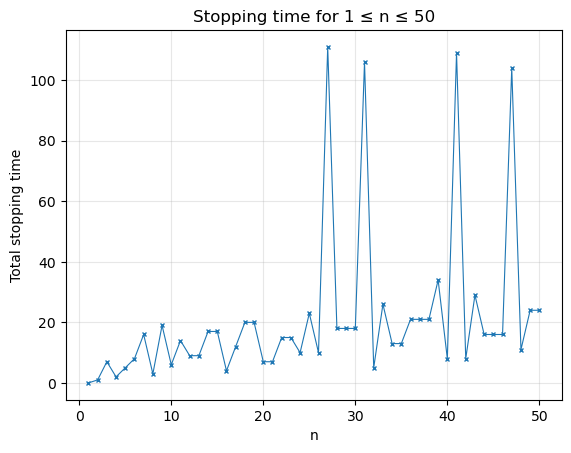

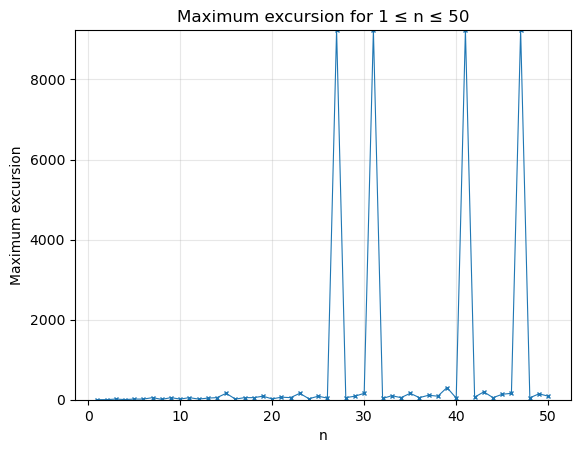

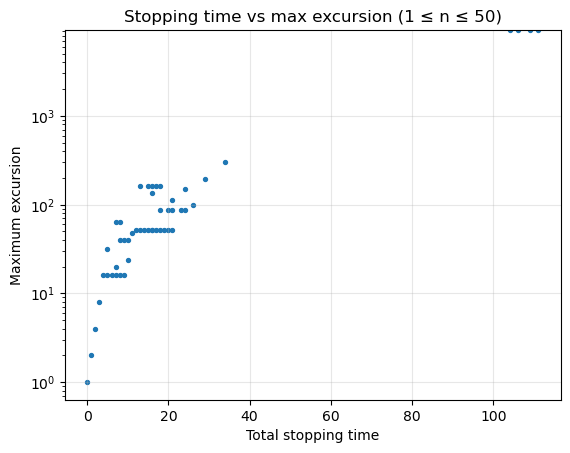


-----------------------------
Running for N = 200
Largest stopping time: 124 at n = 171
Largest maximum excursion: 9232 at n = 27
Average stopping time: 42.09
Range of stopping times: 0 to 124
Range of maximum excursions: 1 to 9232


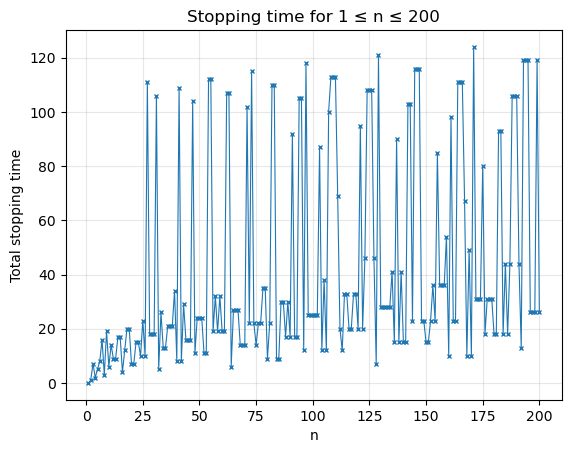

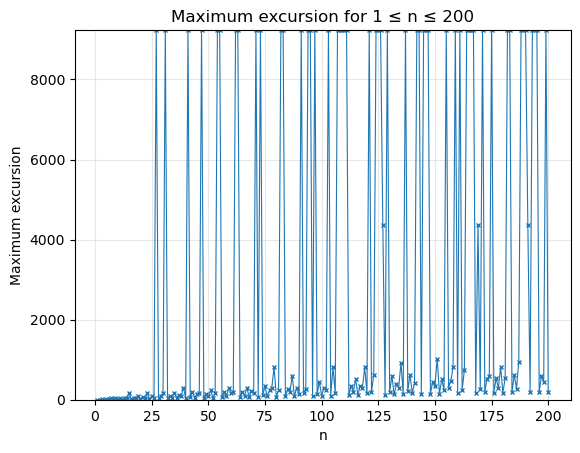

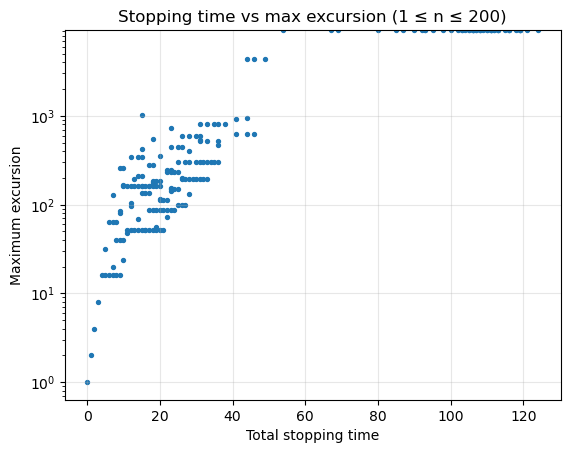


-----------------------------
Running for N = 500
Largest stopping time: 143 at n = 327
Largest maximum excursion: 39364 at n = 447
Average stopping time: 52.286
Range of stopping times: 0 to 143
Range of maximum excursions: 1 to 39364


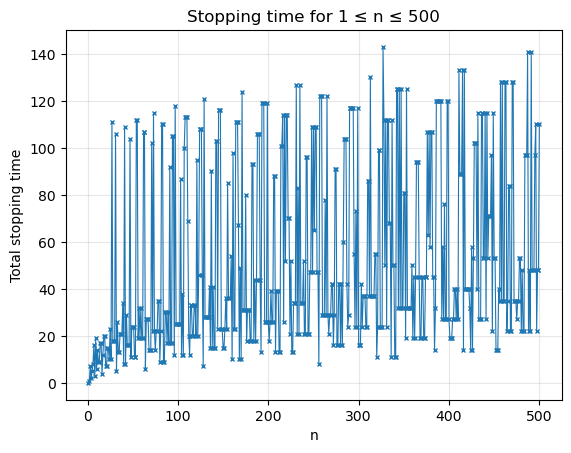

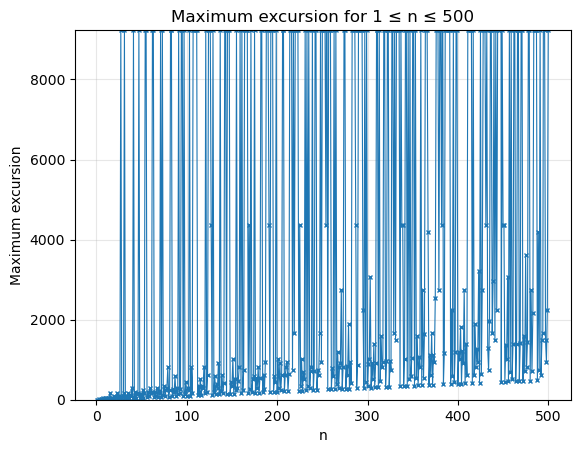

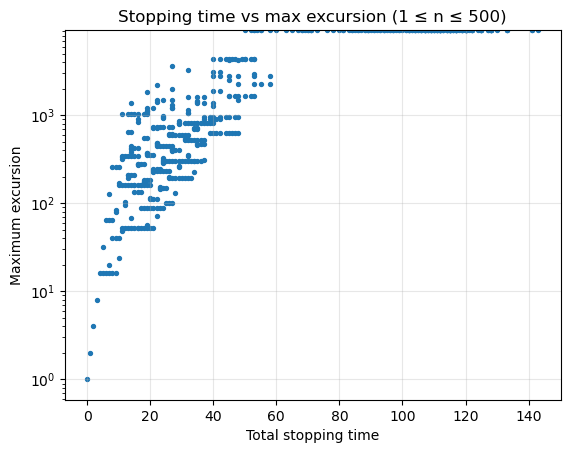

In [134]:
import section1_standard_behaviour as s1

N_values2 = [50, 200, 500]

for N in N_values2:

    print("\n-----------------------------")
    print("Running for N =", N)

    n_val, stop_t, n_exc = s1.collatz_simulations(N)

    # Compute ranges first
    stop_min = min(stop_t)
    stop_max = max(stop_t)

    exc_min = min(n_exc)
    exc_max = max(n_exc)

    # Find where maxima occur
    n_stop = n_val[stop_t.index(stop_max)]
    n_exc_at_max = n_val[n_exc.index(exc_max)]

    print("Largest stopping time:", stop_max, "at n =", n_stop)
    print("Largest maximum excursion:", exc_max, "at n =", n_exc_at_max)

    print("Average stopping time:", round(sum(stop_t)/len(stop_t), 3))
    print("Range of stopping times:", stop_min, "to", stop_max)
    print("Range of maximum excursions:", exc_min, "to", exc_max)

    s1.plot_stopping_time(N)
    s1.plot_max_excursion(N)
    s1.stopping_vs_excursion(N)

#### Stopping Time Plots:

For N = 50, we can already observe noticeable variation between neighbouring starting values. There doesn’t initially appear to be any clear pattern, aside from a slight increase in stopping times, although this may simply be due to considering the first few integers.

When compared with the behaviour for N = 200 and N = 500, it reinforces how unpredictable the sequence is. The stopping times vary significantly even between nearby values of n, and there is no obvious trend. If anything, the irregularity seems to become more pronounced as the range increases.

#### Maximum Excursion Plots:

For N = 50, the maximum excursion plots are already show that many sequences increase well beyond their starting value before eventually decreasing to 1. We can see that some values do remain relatively small, whereas others grow much larger, even in this small sample of numbers. We can also link this to branches of the Collatz Tree, as some numbers never get higher than their starting point, for example the main branch 1,2,4,8,16,32,64, which always decreases.

When comparing this to N = 200 and N = 500, we can see that this exact behaviour becomes more pronnounced. Maximum values are much higher, and the variation appears more noticeable. Similar to stopping times, there is no apparent pattern, as the growth also seems fairly irregular.

#### Stopping Times and Maximum Excursion: 

From both these plots, we can see that although all of these sequences eventually decrease and reach 1, they take very different paths to get there. Some have longer sequences, some reach higher values, and some exhibit both behaviours, while others show neither. This is consistent with the Collatz conjecture, as all tested values still converge despite the irregular behaviour.

Additionally, there does not appear to be a strong or consistent relationship between maximum excursion and stopping time. While some values that reach high maximum values also have long stopping times, this is not always the case, suggesting that these two aspects of the sequence behave somewhat independently.

## Section 3: Variants of the Collatz Rule

In this section, we investigate how the behaviour of the Collatz sequence changes when the rule is varied.

### How are we changing the Collatz sequence?

Our aim is to modify the sequence and see if similar rules continue to exhibit the same properties of the standard Collatz sequence.

We will do this by replacing the usual '3n + 1' rule for odd values with variants of the more general form 'an + b'. This allows us to compare how small changes to the rule affect the behaviour of the sequence.

Before getting a final function for a variant sequence, we first focus on describing a single step of an 'an + b' sequence.

In [135]:
def validate_input(n):
    '''
    Checks if input is valid
    '''
    if type(n) != int:
        raise TypeError("n must be an integer")
    if n <= 0:
        raise ValueError("n must be positive")


def variant_step(n, a, b):
    '''
    Does one step of a Collatz-type rule
    '''
    validate_input(n)

    if n % 2 == 0:
        return n // 2
    else:
        return a * n + b

We also include a similar input validation function so that only positive integers are accepted.

We can now compute one step of a chosen variant sequence, for example:

In [136]:
variant_step(3, 1, 1)

4

### Modifying the Rule

We now define a function called `variant_sequence()`. This function builds upon `variant_step()` by generating the full sequence for a selected rule, while also tracking how the sequence behaves for a given starting value.

Unlike the standard Collatz sequence, these variants do not always converge to 1. Instead, a sequence may reach 1, grow rapidly, or enter a cycle.

For this reason, the function records the values produced and identifies how the sequence ends, allowing us to compare behaviour across different cases.

In [137]:
def variant_sequence(start, a, b, max_steps=100, cap=10**6):
    '''
    Generates a full sequence for a Collatz-type rule
    '''
    validate_input(start)

    sequence = [start]
    seen = {start}
    n = start
    status = "iteration_limit_reached"

    for i in range(max_steps):
        if n == 1:
            status = "reached_1"
            break

        n = variant_step(n, a, b)
        sequence.append(n)

        if n > cap:
            status = "too_large"
            break

        if n in seen:
            status = "cycle"
            break

        seen.add(n)

    return sequence, status

This time, we test the behaviour of the sequence for two similar variants, '3n - 1' and '3n + 3', using starting values n = 10 and n = 15.

For 3n - 1:

In [138]:
variant_sequence(10,3,-1)

([10, 5, 14, 7, 20, 10], 'cycle')

In [139]:
variant_sequence(15,3,-1)

([15, 44, 22, 11, 32, 16, 8, 4, 2, 1], 'reached_1')

For 3n + 3:

In [140]:
variant_sequence(10,3,3)

([10, 5, 18, 9, 30, 15, 48, 24, 12, 6, 3, 12], 'cycle')

In [141]:
variant_sequence(15,3,3)

([15, 48, 24, 12, 6, 3, 12], 'cycle')

From the outputs above, we can clearly see that these sequences have demonstrate the different types of behaviour that may occur, as well as how the function handles them.

### PLace

.


-----------------------------
Standard Collatz (3n+1)
Reached 1: 46
Cycles: 0
Grew too large: 0
Step limit reached: 4
Proportion reaching 1: 0.92


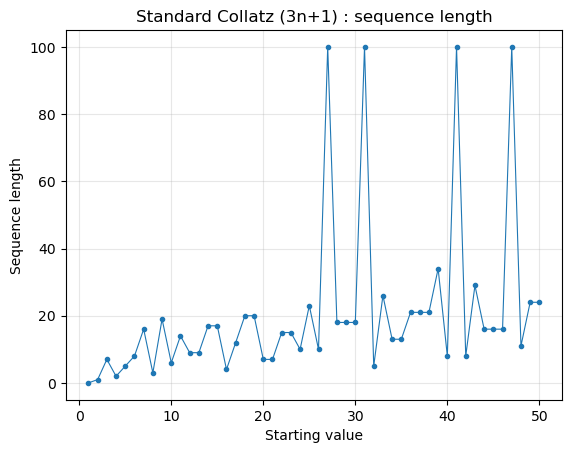

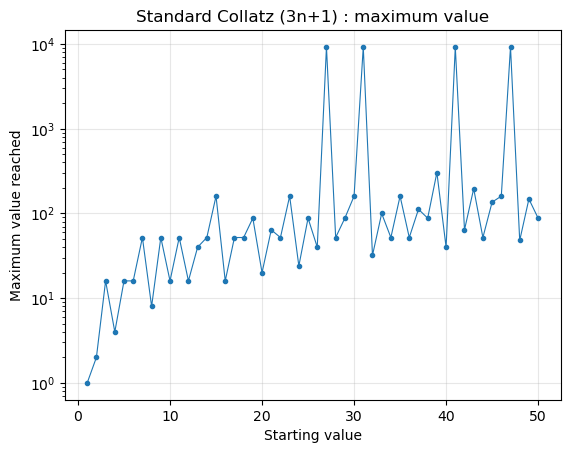


-----------------------------
Variant 5n+1
Reached 1: 15
Cycles: 11
Grew too large: 24
Step limit reached: 0
Proportion reaching 1: 0.3


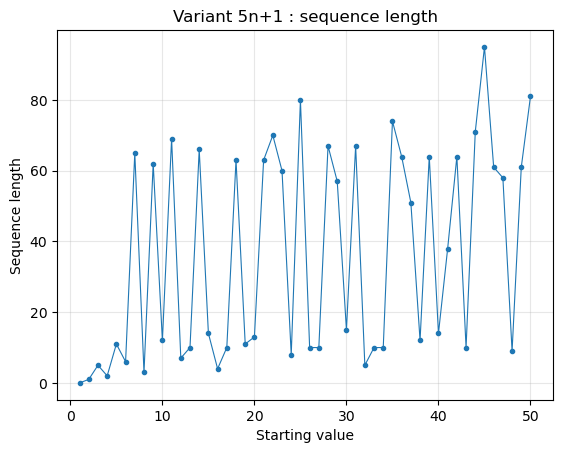

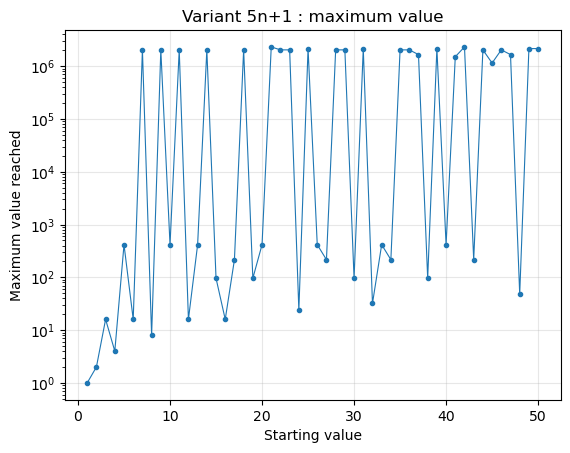


-----------------------------
Variant 5n+3
Reached 1: 8
Cycles: 13
Grew too large: 29
Step limit reached: 0
Proportion reaching 1: 0.16


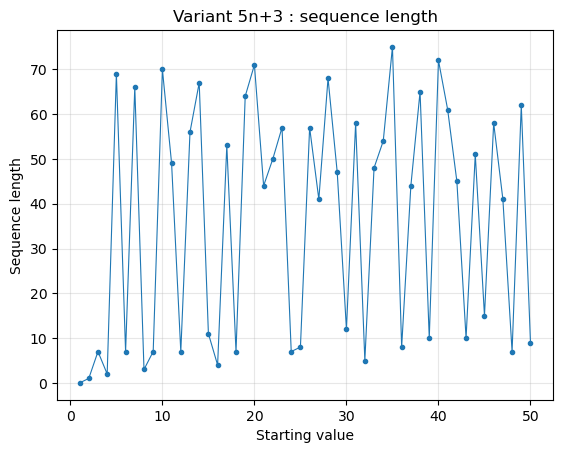

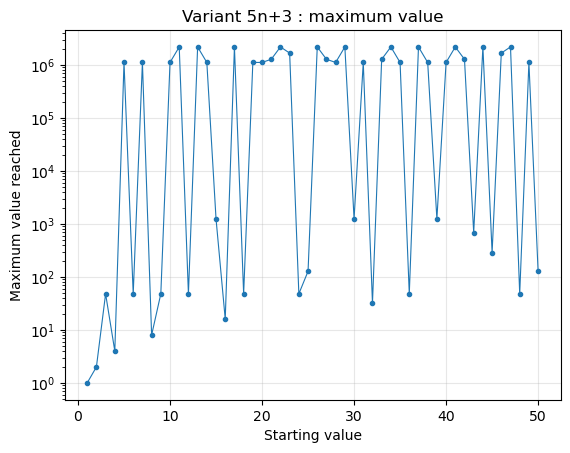

In [142]:
import section3_variants as s3

variants = [
    ("Standard Collatz (3n+1)", "3n1", 3, 1),
    ("Variant 5n+1", "5n1", 5, 1),
    ("Variant 5n+3", "5n3", 5, 3)]

start = 7
N = 50
max_steps = 100
cap = 10**6

for name, label, a, b in variants:
    print("\n-----------------------------")
    s3.summary_variant(name, N, a, b, max_steps=max_steps, cap=cap)

    s3.plot_variant_lengths(name, label, N, a, b, max_steps=max_steps, cap=cap)
    s3.plot_variant_max_values(name, label, N, a, b, max_steps=max_steps, cap=cap)

## Section 4: The Collatz Tree

In this final section, I decided to do a bit of work on the Collatz Tree. After watching an interesting video by 'Veritasium' on the Collatz sequence, which included a range of visualisations produced by mathematicians, some of which were based on Collatz trees, I was inspired to define some simple functions to generate them. This then allowed me to produce outputs and explore their structure in a little more detail.

### What is a Collatz Tree?

The Collatz Tree focuses on defining the Collatz sequence in reverse. Instead of starting at an initial number and iterating the usual rule, we work backwards from 1 and consider what numbers would lead to it after each step. We can repeat this process for each level, creating branches of possible predecessors (or 'children') from each parent node.
  
For a given value \(n\), its possible predecessors are:

$$
\text{Parents}(n) =
\begin{cases}
2n, \\
\frac{n - 1}{3}, \quad \text{if } \frac{n - 1}{3} \in \mathbb{Z}, \text{ is odd, and positive}.
\end{cases}
$$

For any number n, there is always a possible predecessor of 2n. In some cases, this may be the only predecessor, or it may be accompanied by (n−1)/3, but only if this value is a positive odd integer. This means nodes have either one or two predecessors, which creates a tree-like, branching structure as we continue the process.

If we continue this indefinitely, it provides a way of visualising how all numbers eventually connect back to 1 - an alternative way to view the problem. However, in practice this becomes too complex to fully represent, so here the focus is on creating a simple process to generate part of the Collatz tree and display its levels.

Below are the first core functions, stated in ```collatz_tree.py``` which build the core steps of the Collatz Tree:

In [143]:
def node_parents(n):
    '''
    Creates parent nodes for one value n, similar to doing one_step()
    '''
    parents = []

    parents.append(2*n)

    if (n-1)%3 == 0:
        m = (n-1)//3
        if m%2 == 1 and m>0:
            parents.append(m)

    return parents

In [144]:
node_parents(4)

[8, 1]

In [145]:
node_parents(17)

[34]

In [146]:
def tree_generator(depth):
    '''
    Generates a set amount of layers of the Collatz Tree
    '''
    levels = []
    levels.append([1])      # level 0 starts with 1

    seen = [1]

    for i in range(depth):

        current_level = levels[i]
        next_level = []

        for n in current_level:
            for parent in node_parents(n):
                if parent not in seen:
                    next_level.append(parent)
                    seen.append(parent)

        levels.append(next_level)

    return levels

In [147]:
tree_generator(1)

[[1], [2]]

In [148]:
tree_generator(4)

[[1], [2], [4], [8], [16]]

As you can see ```node_parents()``` returns the predecessors for a set starting value 'n' and ```tree_generator()``` uses this initial function and iterates it from 1, to find all the predecessors in each level.

### Investigating tree structure

Obviously, it is very open ended from where you can go from here. I decided to investigate the structure of the trees and how can compare values as the depth increases.

#### Looking at the tree computations on their own

First to compute a set amount of levels and just look at this output individually.

In [149]:
depth = 8
levels = tree_generator(depth)

print("\nTree structure:")

for i in range(len(levels)):
    print("Level", i, ":", levels[i])
    print("Nodes in level:", len(levels[i]))
    print()


Tree structure:
Level 0 : [1]
Nodes in level: 1

Level 1 : [2]
Nodes in level: 1

Level 2 : [4]
Nodes in level: 1

Level 3 : [8]
Nodes in level: 1

Level 4 : [16]
Nodes in level: 1

Level 5 : [32, 5]
Nodes in level: 2

Level 6 : [64, 10]
Nodes in level: 2

Level 7 : [128, 21, 20, 3]
Nodes in level: 4

Level 8 : [256, 42, 40, 6]
Nodes in level: 4



As we can already see, printing the output in this way is a useful way of showing how each level is structured, rather than outputting all the nodes at once. It also highlights how the tree grows as we move further away from 1. We can begin to visualise how the branches are arranged, and it becomes clear that they are starting to split off as the levels increase.

#### Visualising the structure